In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Numerosity Data Reduction

### Random Sampling

In [2]:
customer_df = pd.read_csv('Customer Churn.csv')
customer_df.head(3)

,Call Failure,Complains,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Status,Churn
0,8,0,38,4370,71,5,17,1,0
1,0,0,39,318,5,7,4,0,0
2,10,0,37,2453,60,359,24,1,0


In [3]:
customer_df.shape

(3150, 9)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [11]:
y = customer_df['Churn']
#X = customer_df[customer_df['Churn']==False]
X = customer_df.drop(columns='Churn')

In [15]:
# Decision tree model without sampling
param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[10,20,30,40,50,60],
    'min_samples_split': [10,20,30,40,50],
    'min_impurity_decrease': [0,0.001,0.005, 0.01, 0.05, 1]}

gridSearch = GridSearchCV(DecisionTreeClassifier(),
                          param_grid,
                          cv=3,
                          scoring='recall',
                          verbose=1).fit(X,y)
print('Best score: ', gridSearch.best_score_)
print('Best parameters: ', gridSearch.best_params_)


Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best score:  0.7353535353535353
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'min_impurity_decrease': 0.005, 'min_samples_split': 40}


In [16]:
# Decision tree model with sampling
customer_df_rs = customer_df.sample(1000, random_state=1)
y = customer_df_rs['Churn']
X = customer_df_rs.drop(columns='Churn')

In [17]:
gridSearch = GridSearchCV(DecisionTreeClassifier(),
                          param_grid,
                          cv=3,
                          scoring='recall',
                          verbose=1).fit(X,y)
print('Best  score: ', gridSearch.best_score_)
print('Best parameters: ', gridSearch.best_params_)

Fitting 3 folds for each of 360 candidates, totalling 1080 fits
Best score:  0.7430555555555555
Best parameters:  {'criterion': 'entropy', 'max_depth': 10, 'min_impurity_decrease': 0.005, 'min_samples_split': 10}


In [19]:
from sklearn.tree import export_graphviz
import graphviz

In [22]:
# Decision tree using best_params_ from sampling above
# Do not use sampling data 
y = customer_df['Churn']
X = customer_df.drop(columns='Churn')

classTree = DecisionTreeClassifier(criterion='entropy',
                                   max_depth=10,
                                   min_samples_split=10,
                                   min_impurity_decrease=0.005).fit(X,y)

dot_data = export_graphviz(classTree,
                           out_file=None,
                           feature_names = X.columns,
                           class_names=['Not Churn',
                                        'Churn'],
                           filled=True,
                           rounded=True,
                           special_characters=True)
graph = graphviz.Source(dot_data)
graph.render(filename='ChurnDT')

'ChurnDT.pdf'

In [23]:
customer_df['Churn'].value_counts(normalize=True)

Churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

In [24]:
for i in range(3):
    print(customer_df.sample(1000)['Churn'].value_counts(normalize=True))

Churn
0    0.861
1    0.139
Name: proportion, dtype: float64
Churn
0    0.833
1    0.167
Name: proportion, dtype: float64
Churn
0    0.853
1    0.147
Name: proportion, dtype: float64


In [25]:
customer_df_rs['Churn'].value_counts(normalize=True)

Churn
0    0.856
1    0.144
Name: proportion, dtype: float64

### Stratified sampling

In [28]:
n,s = len(customer_df),1000
r=s/n
sample_df = customer_df.groupby('Churn', group_keys=False).apply(lambda sdf: sdf.sample(round(len(sdf)*r)))
print(sample_df['Churn'].value_counts(normalize=True))

Churn
0    0.843
1    0.157
Name: proportion, dtype: float64


In [30]:
customer_df['Churn'].value_counts(normalize=True)

Churn
0    0.842857
1    0.157143
Name: proportion, dtype: float64

### Random Over/Undersampling

In [32]:
n,s=len(customer_df),500
sample_df = customer_df.groupby('Churn', group_keys=False).apply(lambda sdf: sdf.sample(250))
print(sample_df.Churn.value_counts(normalize=True))

Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


## Dimensionality Data Reduction

### Linear Regression as a dimension reduction method

In [34]:
amzn_df = pd.read_csv('amznStock.csv')
amzn_df.set_index('t', drop=True, inplace=True)
amzn_df.columns = ['pd_changeP', 'pw_changeP', 'dow_pd_changeP',
       'dow_pw_changeP', 'nasdaq_pd_changeP', 'nasdaq_pw_changeP',
       'changeP']
amzn_df.head(3)

,pd_changeP,pw_changeP,dow_pd_changeP,dow_pw_changeP,nasdaq_pd_changeP,nasdaq_pw_changeP,changeP
t,,,,,,,
2019-08-23,-1.035349,-1.078743,0.188949,-0.105289,-0.333497,-0.268107,-3.049884
2019-08-26,-3.049884,-0.756680,-2.374425,0.586671,-3.145535,-0.335637,1.100239
2019-08-27,1.100239,-0.408193,1.053224,1.248816,1.473944,1.204158,-0.397996


In [35]:
amzn_df.shape

(350, 7)

In [37]:
import statsmodels.api as sm

In [40]:
# drop both the changedP column and the row '2021-01-12'
X = amzn_df.drop(columns=['changeP'],
                 index=['2021-01-12'])

# add the constant value 1 to the dataframe for calculating the intercept
X = sm.add_constant(X)

# set the dependent attribute as changeP field
y = amzn_df.drop(index=['2021-01-12']).changeP

sm.OLS(y, X).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,0.2342,0.122,1.926,0.055,-0.005,0.473
pd_changeP,-0.0804,0.112,-0.719,0.473,-0.300,0.140
pw_changeP,0.0665,0.044,1.499,0.135,-0.021,0.154
dow_pd_changeP,-0.2888,0.151,-1.914,0.056,-0.586,0.008
dow_pw_changeP,0.0866,0.066,1.316,0.189,-0.043,0.216
nasdaq_pd_changeP,0.0919,0.210,0.438,0.661,-0.321,0.505
nasdaq_pw_changeP,-0.1403,0.098,-1.433,0.153,-0.333,0.052


In [41]:
from sklearn.linear_model import LinearRegression

In [48]:
lm = LinearRegression().fit(X,y)
print('intercept (b0) ', lm.intercept_)

coef_names = ['b1','b2','b3','b4','b5','b6']
print(pd.DataFrame({'Predictor': X.columns[1:], 
                    'coefficient Name': coef_names,
                    'coefficient Value': lm.coef_[1:]}))

intercept (b0)  0.2342084443599448
           Predictor coefficient Name  coefficient Value
0         pd_changeP               b1          -0.080374
1         pw_changeP               b2           0.066490
2     dow_pd_changeP               b3          -0.288781
3     dow_pw_changeP               b4           0.086627
4  nasdaq_pd_changeP               b5           0.091948
5  nasdaq_pw_changeP               b6          -0.140282


* Both the statsmodel.api OLS linear regression model and the sklearn LinearRegression model had similar coefficients between the two models

* only the dow_pd_changeP attribute has some relationship to the changeP

In [49]:
X = amzn_df.drop(index=['2021-01-12']).dow_pd_changeP
X = sm.add_constant(X)
y = amzn_df.drop(index =['2021-01-12']).changeP
sm.OLS(y,X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                changeP   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     19.40
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           1.42e-05
Time:                        12:51:17   Log-Likelihood:                -752.14
No. Observations:                 349   AIC:                             1508.
Df Residuals:                     347   BIC:                             1516.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1975      0.112      1.761      0.079      -0.023       0.418
dow_pd_changeP    -0.2470      0.056     -4.404      0.000      -0.357      -0.137
==============================================================================
Omnibus:                       26.140   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               99.897
Skew:                          -0.037   Prob(JB):                     2.03e-22
Kurtosis:                       5.620   Cond. No.                         2.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Random Forest as a Dimension Reduction method

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
y=customer_df['Churn']
X = customer_df.drop(columns=['Churn'])
rf = RandomForestClassifier(n_estimators=1000)
rf.fit(X,y)

RandomForestClassifier(n_estimators=1000)

In [54]:
rf.feature_importances_

array([0.07120721, 0.20374193, 0.1284689 , 0.15851901, 0.13059305,
       0.07875594, 0.09488652, 0.13382744])

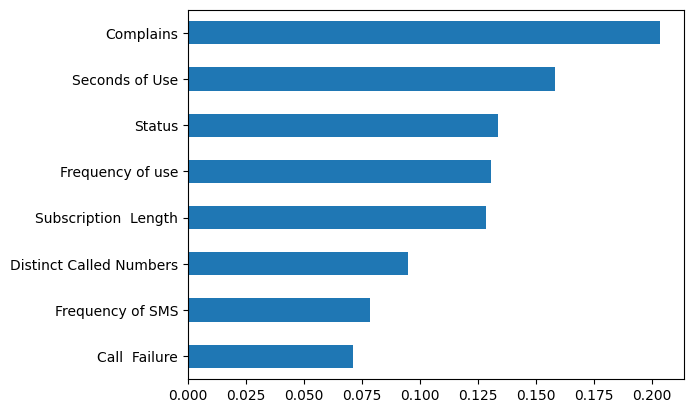

In [56]:
importance_sr = pd.Series(rf.feature_importances_, index=X.columns)
importance_sr.sort_values(ascending=True).plot.barh()
plt.show()

### Brute-force Computational Dimension Reduction

In [58]:
import itertools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import GridSearchCV

In [74]:
in_atts = ['Call  Failure', 'Complains', 'Subscription  Length',
           'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 
           'Distinct Called Numbers', 'Status']
n_in_atts = len(in_atts)
result_df = pd.DataFrame(columns = ['subset_candidate','best_k',
                                     'performance'])
customer_df_std = (customer_df - customer_df.min())/(
                   customer_df.max()-customer_df.min())

for n in range(1,n_in_atts+1):
    for atts in itertools.combinations(in_atts, r=n):
        atts=list(atts)
        X = customer_df_std[atts]
        y = customer_df['Churn']
        
        # Tune KNN
        param_grid = {
            'n_neighbors':[1,3,5,7]}
        gridSearch = GridSearchCV(KNeighborsClassifier(),
                                param_grid, cv=2, scoring='recall')
        gridSearch.fit(X,y)
        best_k = gridSearch.best_params_['n_neighbors']
        
        # Train the tuned KNN
        knn=KNeighborsClassifier(best_k).fit(X,y)
        
        # Prediction
        y_predict = knn.predict(X)
        
        # Performance evaluation
        dic_append = {'subset_candidate':atts,
                      'best_k':best_k,
                      'performance': recall_score(y, y_predict)}
        
        # Recording and reporting
        result_df.loc[len(result_df)] = dic_append
        #print(dic_append)

In [75]:
dic_append

{'subset_candidate': ['Call  Failure',
  'Complains',
  'Subscription  Length',
  'Seconds of Use',
  'Frequency of use',
  'Frequency of SMS',
  'Distinct Called Numbers',
  'Status'],
 'best_k': 3,
 'performance': 0.9191919191919192}

In [76]:
result_df.sort_values('performance', ascending=False).head(5)

,subset_candidate,best_k,performance
62,"[Complains, Seconds of Use, Frequency of use]",1,1.00000
173,"[Call Failure, Complains, Seconds of Use, Fre...",1,0.99798
137,"[Complains, Seconds of Use, Frequency of use, ...",1,0.99798
138,"[Complains, Seconds of Use, Frequency of use, ...",1,0.99798
99,"[Call Failure, Complains, Seconds of Use, Dis...",1,0.99798


## Principal Component Analysis (PCA

In [78]:
toy_df = pd.read_excel('PCA_toy_dataset.xlsx')
toy_df.head(3)

,Dimension_1,Dimension_2
0,41,52
1,50,64
2,64,52


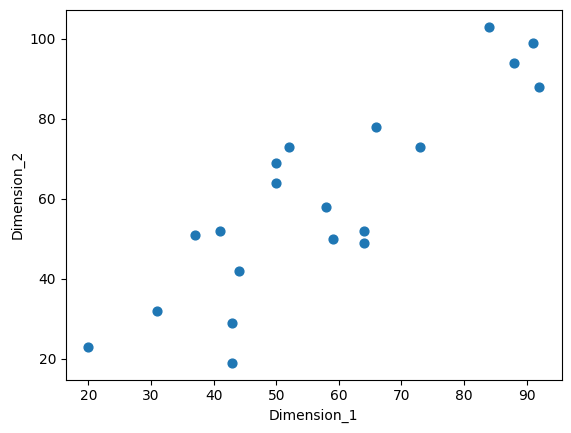

In [79]:
# Plot shows a correlation between the 2 attributes
toy_df.plot.scatter(x='Dimension_1', y='Dimension_2', s=40)
plt.show()

In [81]:
# Variance is split 40-60
var_df = pd.DataFrame(toy_df.var())
var_df.columns=['Variance']
var_df.reset_index(inplace=True)
var_df

,index,Variance
0,Dimension_1,415.315789
1,Dimension_2,611.673684


In [85]:
var_df.loc[len(var_df)] = {'index':'Total','Variance':var_df['Variance'].sum()}
var_df.set_index('index')

,Variance
index,
Dimension_1,415.315789
Dimension_2,611.673684
Total,1026.989474


In [86]:
# Dimension 1 and Dimension 2 are highly correlated
toy_df.corr()

,Dimension_1,Dimension_2
Dimension_1,1.000000,0.859195
Dimension_2,0.859195,1.000000


In [89]:
from sklearn.decomposition import PCA
pca = PCA().fit(toy_df)

toy_t_df = pd.DataFrame(pca.transform(toy_df))
toy_t_df.columns = ['PC1','PC2']
toy_t_df

,PC1,PC2
0,-16.469846,-7.962674
1,-1.476788,-8.418973
2,-2.116506,10.009016
3,-19.747457,-10.464127
4,51.457824,1.775480
5,19.447434,-4.653743
6,-41.007198,14.194004
7,50.214928,-6.190398
8,-4.460640,11.881191
9,45.678760,2.551638


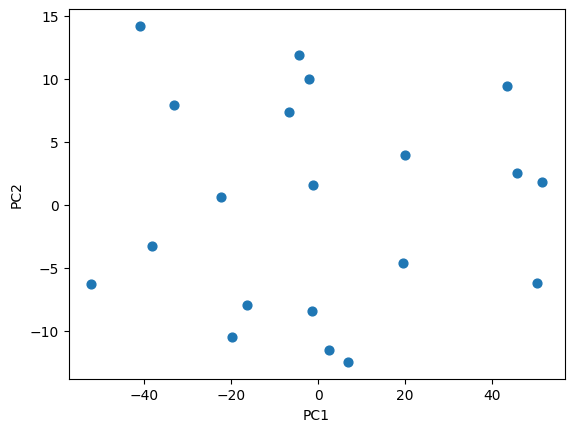

In [91]:
# PC1 and PC2 are scattered with no apparent relationship
toy_t_df.plot.scatter(x='PC1',y='PC2',s=40)
plt.show()

In [92]:
var_df = pd.DataFrame(toy_t_df.var())
var_df.columns=['Variance']
var_df.reset_index(inplace=True)
var_df

,index,Variance
0,PC1,957.537176
1,PC2,69.452298


In [94]:
# Variance has shihfted to PC1
# Variance total has not changed
var_df.loc[len(var_df)] = {'index':'Total','Variance':var_df['Variance'].sum()}
var_df.set_index('index')

,Variance
index,
PC1,957.537176
PC2,69.452298
Total,1026.989474


In [95]:
# PC1 and PC2 are not correlated
toy_t_df.corr()

,PC1,PC2
PC1,1.000000e+00,5.680543e-16
PC2,5.680543e-16,1.000000e+00


### Example – Non-parametric Dimension Reduction

In [96]:
# Load data and pivot to country as the index
report_df = pd.read_csv('WH Report_preprocessed.csv')
country_df = report_df.pivot(index='Name', columns='year',
                             values=['Life_Ladder','Log_GDP_per_capita',
                                     'Social_support','Healthy_life_expectancy_at_birth',
                                     'Freedom_to_make_life_choices',
                                     'Generosity','Perceptions_of_corruption',
                                     'Positive_affect','Negative_affect'])

In [97]:
country_df.head(3)

Life_Ladder                                                   \
year               2010   2011   2012   2013   2014   2015   2016   2017   
Name                                                                       
Afghanistan       4.758  3.832  3.783  3.572  3.131  3.983  4.220  2.662   
Albania           5.269  5.867  5.510  4.551  4.814  4.607  4.511  4.640   
Algeria           5.464  5.317  5.605  5.980  6.355  5.848  5.341  5.249   

                           ... Negative_affect                               \
year          2018   2019  ...            2010   2011   2012    2013   2014   
Name                       ...                                                
Afghanistan  2.694  2.375  ...           0.275  0.267  0.268  0.2730  0.375   
Albania      5.004  4.995  ...           0.300  0.257  0.271  0.3380  0.335   
Algeria      5.043  4.745  ...           0.255  0.255  0.230  0.2035  0.177   

                                                
year          2015   2016   2017   2018   2019  
Name                                            
Afghanistan  0.339  0.348  0.371  0.405  0.502  
Albania      0.350  0.322  0.334  0.319  0.274  
Algeria      0.277  0.377  0.289  0.293  0.215  

[3 rows x 90 columns]

In [98]:
X = country_df

# Standardize the X dataset
X = (X-X.mean())/(X.std())
X.head(3)

Life_Ladder                                                    \
year               2010      2011      2012      2013      2014      2015   
Name                                                                        
Afghanistan   -0.622104 -1.511427 -1.475323 -1.543065 -1.998271 -1.323126   
Albania       -0.190849  0.282957  0.020949 -0.744787 -0.576171 -0.772155   
Algeria       -0.026280 -0.202012  0.103257  0.420421  0.725942  0.323607   

                                                     ... Negative_affect  \
year             2016      2017      2018      2019  ...            2010   
Name                                                 ...                   
Afghanistan -1.128955 -2.567462 -2.660826 -2.784707  ...        0.435211   
Albania     -0.871862 -0.824119 -0.564109 -0.543304  ...        0.768225   
Algeria     -0.138575 -0.287367 -0.528710 -0.757178  ...        0.168800   

                                                                         \
year             2011      2012      2013      2014      2015      2016   
Name                                                                      
Afghanistan  0.251784  0.151250  0.078632  1.392257  0.846426  0.766223   
Albania      0.123794  0.188845  0.867605  0.877238  0.990833  0.452838   
Algeria      0.098196 -0.324944 -0.764963 -1.157086  0.032497  1.115768   

                                           
year             2017      2018      2019  
Name                                       
Afghanistan  1.000075  1.302003  2.385332  
Albania      0.559866  0.318447 -0.165331  
Algeria      0.024478  0.021092 -0.825371  

[3 rows x 90 columns]

In [100]:
X.var().head(3)

             year
Life_Ladder  2010    1.0
             2011    1.0
             2012    1.0
dtype: float64

In [101]:
X.std().head(3)

             year
Life_Ladder  2010    1.0
             2011    1.0
             2012    1.0
dtype: float64

In [104]:
# There are 90 columns
X.shape

(122, 90)

In [105]:
from sklearn.decomposition import PCA

In [106]:
pca=PCA().fit(X)
X_t = pd.DataFrame(pca.transform(X),index = X.index)
X_t.columns = ['PC{}'.format(i) for i in range(1,91)]

In [110]:
X_t.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28',
       'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37',
       'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46',
       'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55',
       'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64',
       'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73',
       'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81', 'PC82',
       'PC83', 'PC84', 'PC85', 'PC86', 'PC87', 'PC88', 'PC89', 'PC90'],
      dtype='object')

In [112]:
X_t.var().head()

PC1    42.983254
PC2    14.485954
PC3     6.477992
PC4     6.150161
PC5     4.761642
dtype: float64

In [114]:
total_variance = X.var().sum()
dic = {'variance_percentage':X_t.var()/total_variance,
       'cumulative_variance_percentage':
       X_t.var().cumsum()/total_variance}

explanation_df = pd.DataFrame(dic)
explanation_df


,variance_percentage,cumulative_variance_percentage
PC1,4.775917e-01,0.477592
PC2,1.609550e-01,0.638547
PC3,7.197769e-02,0.710524
PC4,6.833512e-02,0.778860
PC5,5.290713e-02,0.831767
...,...,...
PC86,4.023476e-08,1.000000
PC87,6.144899e-11,1.000000
PC88,1.560054e-33,1.000000
PC89,1.496708e-33,1.000000


<Axes: xlabel='PC1', ylabel='PC2'>

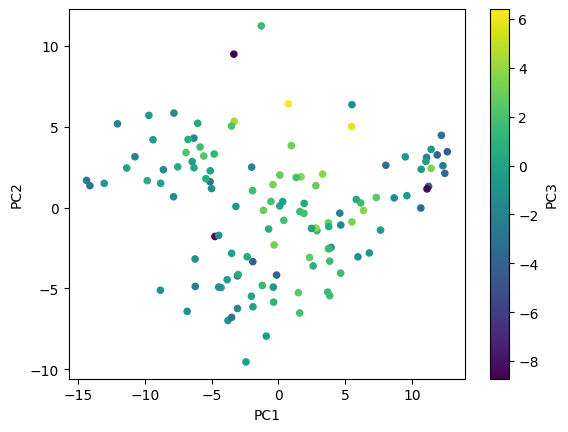

In [115]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False)

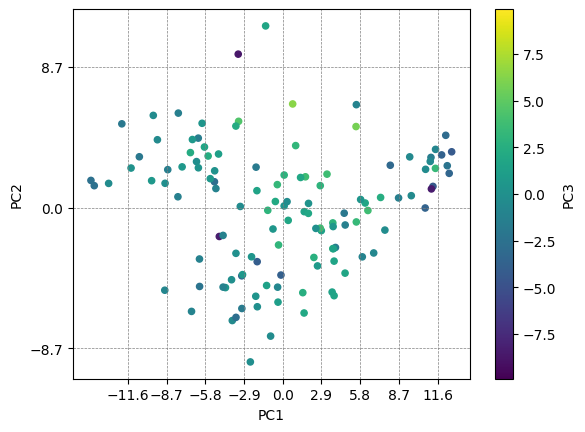

In [117]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False, 
                  vmin=-1/0.101, vmax=1/0.101)

x_ticks_vs = [-2.9*4 + 2.9*i for i in range(9)]
for v in x_ticks_vs:
    plt.axvline(v,c='gray',linestyle='--',linewidth=0.5)
plt.xticks(x_ticks_vs)

y_ticks_vs = [-8.7,0,8.7]
for v in y_ticks_vs:
    plt.axhline(v,c='gray',linestyle='--',linewidth=0.5)
plt.yticks(y_ticks_vs)
plt.show()

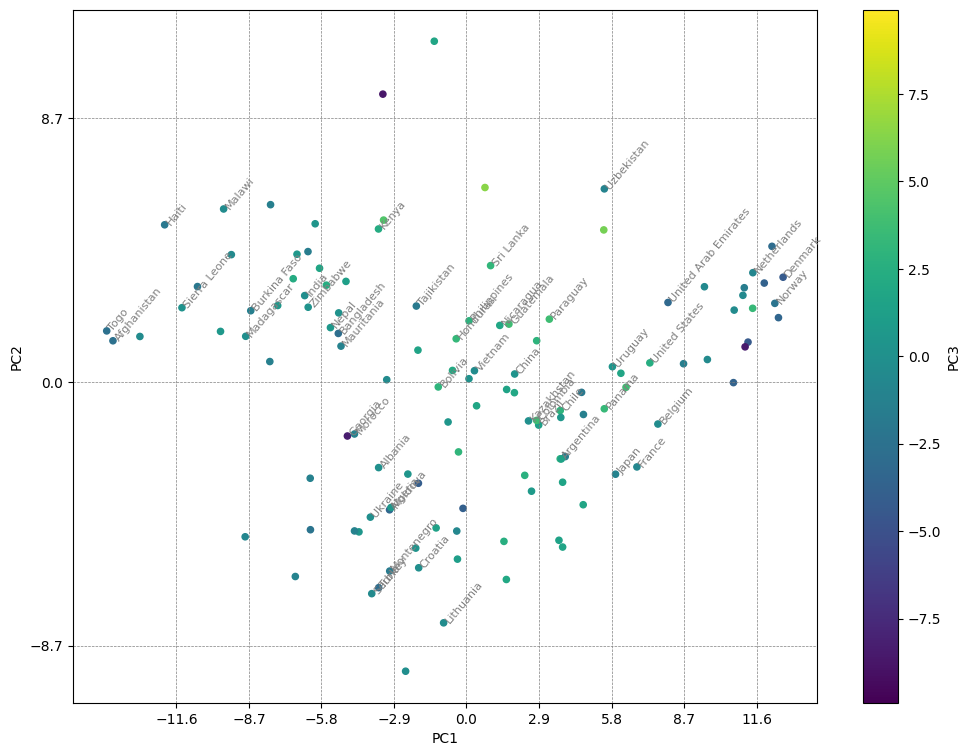

In [119]:
X_t.plot.scatter(x='PC1',y='PC2',c='PC3',sharex=False, 
                  vmin=-1/0.101, vmax=1/0.101,
                  figsize=(12,9))

x_ticks_vs = [-2.9*4 + 2.9*i for i in range(9)]
for v in x_ticks_vs:
    plt.axvline(v,c='gray',linestyle='--',linewidth=0.5)
plt.xticks(x_ticks_vs)

y_ticks_vs = [-8.7,0,8.7]
for v in y_ticks_vs:
    plt.axhline(v,c='gray',linestyle='--',linewidth=0.5)
plt.yticks(y_ticks_vs)

for i, row in X_t.sample(50).iterrows():
    plt.annotate(i, (row.PC1, row.PC2),
                 rotation=50,c='gray',size=8)
plt.show()